In [ ]:
# Data manipulation and processing
import numpy as np
import pandas as pd

# File handling and operations
import os
import glob
import random

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Image processing libraries
from PIL import Image
import cv2
from collections import Counter

In [59]:
path = r"../raw_data/Original"
classes = [c for c in os.listdir(path) if c != ".DS_Store"]
print(classes)

['Non-Stone', 'Stone']


In [ ]:
def make_df(classes,base_dir):
    data = []
    for label in classes:
        folder_path = os.path.join(base_dir, label)
        for file in os.listdir(folder_path):
            if file.endswith(('jpg','png')):
                file_path = os.path.join(folder_path, file)
                data.append((file_path, label))

    df = pd.DataFrame(data, columns=['file_path', 'label'])
    return df

In [ ]:
df = make_df(classes, path)
print("Shape of stroke dataset is:" ,df.shape)

Shape of stroke dataset is: (3364, 2)


In [62]:
df["label"].value_counts()

label
Non-Stone    1787
Stone        1577
Name: count, dtype: int64

In [91]:
path_augmented = r"../raw_data/Augmented"
classes = [c for c in os.listdir(path) if c != ".DS_Store"]

In [92]:
augmented_df = make_df(classes, path_augmented)

In [93]:
augmented_df["label"].value_counts()

label
Non-Stone    19240
Stone        16217
Name: count, dtype: int64

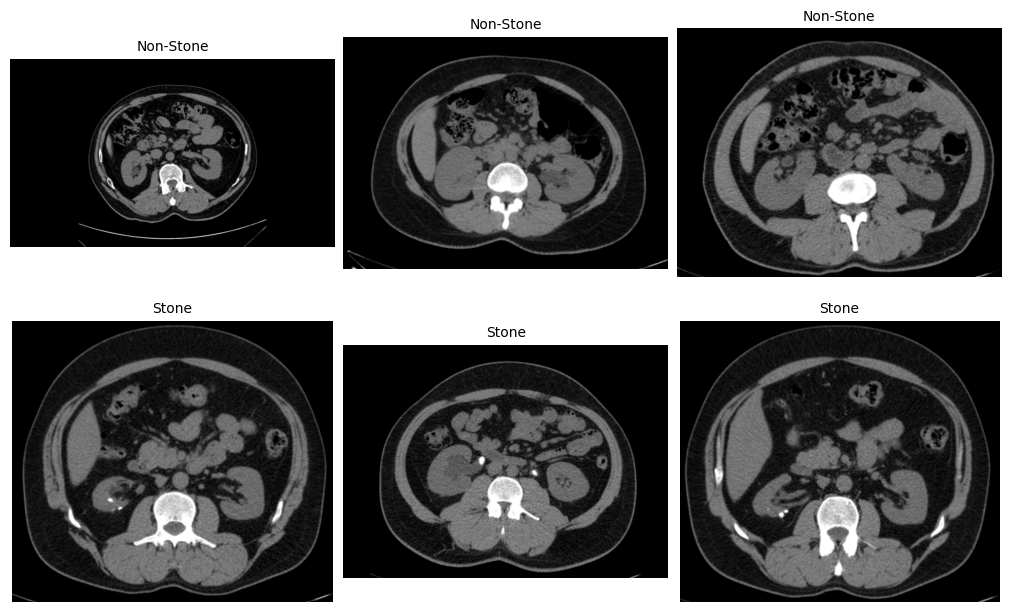

In [ ]:
classes = df['label'].unique()

fig, axes = plt.subplots(len(classes), 3, figsize=(10, 3 * len(classes)), constrained_layout=True)

for i, label in enumerate(classes):
    class_data = df[df['label'] == label]
    num_images_to_show = min(3, len(class_data))  # Show up to 3 or fewer if available

    if num_images_to_show > 0:  # Check if the class has any images
        sample_images = random.sample(list(class_data['file_path']), num_images_to_show)

        for j in range(3):  # Iterate up to 3 to fill the subplot grid
            ax = axes[i, j]
            if j < num_images_to_show:  # Only plot if we have enough images
                img_path = sample_images[j]
                img = mpimg.imread(img_path)
                ax.imshow(img, cmap='gray')  # Show in grayscale
                ax.axis('off')
                ax.set_title(label, fontsize=10)  # Add label under each image
            else:
                ax.axis('off')  # Hide empty subplots

    else:
        for j in range(3):
            axes[i, j].axis('off')  # Hide all subplots for empty class
        print(f"Warning: Class '{label}' has no images.")

plt.show()

In [ ]:
label_mapping = {
    "Non-Stone": 0,
    "Stone": 1
}

df["label"] = df["label"].map(label_mapping)

df.head()

,file_path,label
0,../raw_data/Original/Non-Stone/P066_ME_M_NS_I0...,0
1,../raw_data/Original/Non-Stone/P028_FA_F_NS_I1...,0
2,../raw_data/Original/Non-Stone/P133_RA_F_NS_I3...,0
3,../raw_data/Original/Non-Stone/P110_RA_M_NS_I0...,0
4,../raw_data/Original/Non-Stone/P133_RA_F_NS_I2...,0


In [65]:
df.label.value_counts()

label
0    1787
1    1577
Name: count, dtype: int64

Class distribution

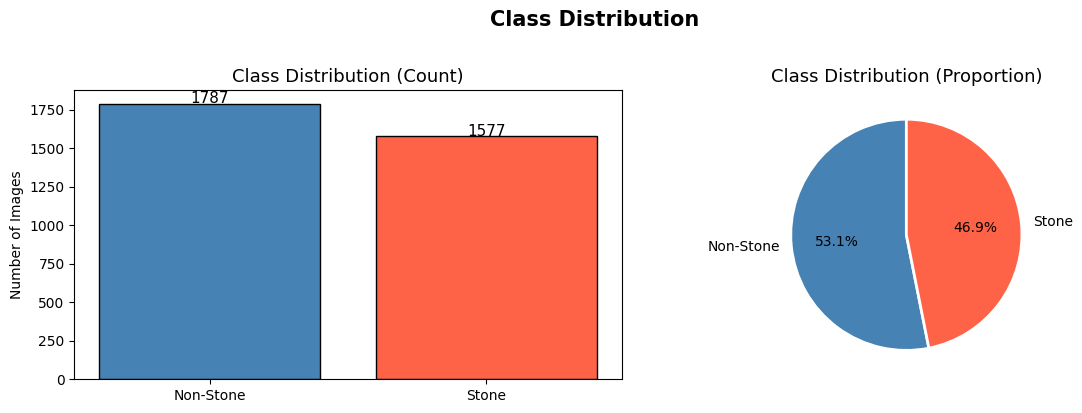

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['label'].value_counts()
label_names = {0: "Non-Stone", 1: "Stone"}
axes[0].bar(
    [label_names[k] for k in counts.index],
    counts.values,
    color=["steelblue", "tomato"],
    edgecolor="black"
)
axes[0].set_title("Class Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Number of Images")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[label_names[k] for k in counts.index],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Class Distribution (Proportion)", fontsize=13)

plt.suptitle("Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

IMAGE DIMENSIONS & ASPECT RATIOS


Image Dimension Statistics:
         width  height  aspect_ratio
count   300.00  300.00        300.00
mean    950.69  621.84          1.50
std     266.99  103.29          0.20
min     397.00  280.00          1.05
25%     712.00  537.00          1.34
50%     836.00  605.50          1.46
75%    1275.00  737.00          1.73
max    1275.00  737.00          1.73

Unique sizes  : 185
Channel modes : Counter({4: 184, 3: 116})


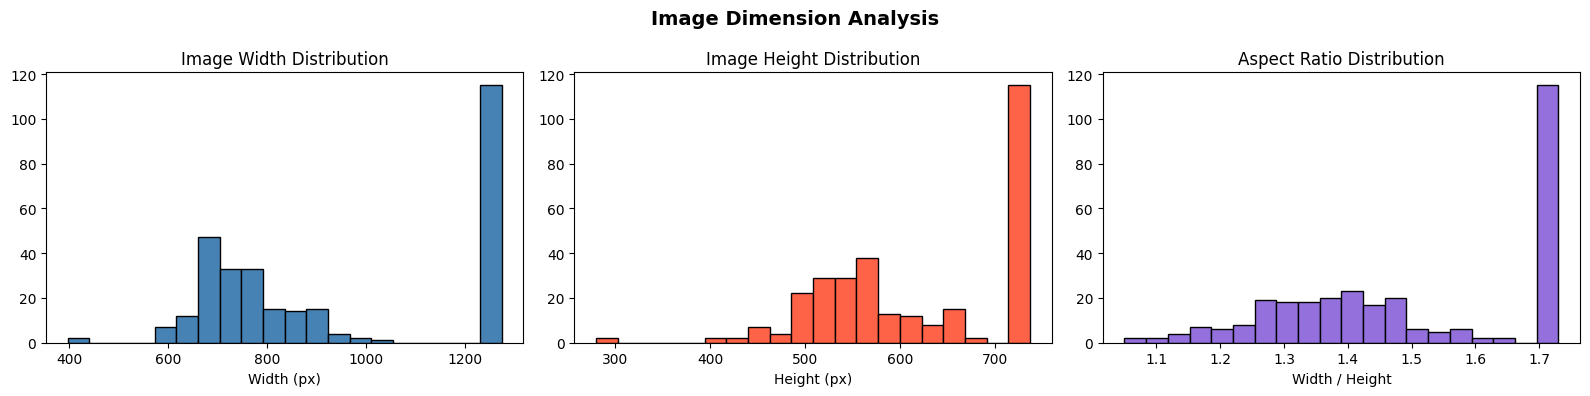

In [94]:
sample_size = min(300, len(df))
sample_df = df.sample(sample_size, random_state=42).reset_index(drop=True)

widths, heights, channels_list, aspect_ratios = [], [], [], []

for fp in sample_df["file_path"]:
    try:
        img = Image.open(fp)
        w, h = img.size
        mode = img.mode
        widths.append(w)
        heights.append(h)
        channels_list.append(len(img.getbands()))
        aspect_ratios.append(round(w / h, 2))
    except Exception as e:
        print(f"Could not read {fp}: {e}")

sample_df["width"]        = widths
sample_df["height"]       = heights
sample_df["channels"]     = channels_list
sample_df["aspect_ratio"] = aspect_ratios

print("\nImage Dimension Statistics:")
print(sample_df[["width", "height", "aspect_ratio"]].describe().round(2))
print(f"\nUnique sizes  : {sample_df.apply(lambda r: f'{int(r.width)}x{int(r.height)}', axis=1).nunique()}")
print(f"Channel modes : {Counter(channels_list)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(sample_df["width"],  bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

axes[1].hist(sample_df["height"], bins=20, color="tomato", edgecolor="black")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

axes[2].hist(sample_df["aspect_ratio"], bins=20, color="mediumpurple", edgecolor="black")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")

plt.suptitle("Image Dimension Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [89]:
print("EDA SUMMARY")
print("=" * 50)
print(f"  Total images       : {len(df)}")
print(f"  Non-Stone (0)      : {(df['label']==0).sum()}")
print(f"  Stone     (1)      : {(df['label']==1).sum()}")
print(f"  Sampled width  avg : {np.mean(widths):.1f} px")
print(f"  Sampled height avg : {np.mean(heights):.1f} px")
print(f"  Aspect ratio avg   : {np.mean(aspect_ratios):.2f}")
print(f"  Channel modes      : {Counter(channels_list)}")

EDA SUMMARY
  Total images       : 3364
  Non-Stone (0)      : 1787
  Stone     (1)      : 1577
  Sampled width  avg : 950.7 px
  Sampled height avg : 621.8 px
  Aspect ratio avg   : 1.50
  Channel modes      : Counter({4: 184, 3: 116})
